In [48]:
from matplotlib import pyplot as plt
import numpy as np

In [49]:
data = np.load("../export.npz")
t = data["t"]
f = data["f"]
current_recon = data["current_recon"]
current_input = data["current_input"]
mag_recon = data["mag_recon"]
mag_input = data["mag_input"]
phase_recon = data["phase_recon"]
phase_input = data["phase_input"] 

In [50]:
mask = (f > 119) & (f < 333)
fc = f[mask]
mag_c = mag_input[mask]

In [51]:
ff = np.vstack((np.ones_like(fc), fc**2, fc**4)).T
c0, c2, c4 = np.linalg.lstsq(ff, np.log(mag_c), rcond=None)[0]
c0, c2, c4

(np.float64(-2.5164501715697343),
 np.float64(-7.00629430100153e-05),
 np.float64(5.656996936810237e-10))

In [52]:
def quartic_taper(f, f_x, f_y):
    """
    Taper for the c4*f^4 term:
      - 1 for |f| <= f_x
      - smooth quintic decay on f_x < |f| < f_y
      - 0 for |f| >= f_y
    """
    if not (0 <= f_x < f_y):
        raise ValueError("Need 0 <= f_x < f_y")

    f = np.asarray(f, dtype=float)
    a = np.abs(f)

    T = np.zeros_like(a)

    # fully on
    T[a <= f_x] = 1.0

    # transition region
    m = (a > f_x) & (a < f_y)
    u = (a[m] - f_x) / (f_y - f_x)
    T[m] = 1 - 10*u**3 + 15*u**4 - 6*u**5

    # fully off already zero
    return T

In [53]:
fl = np.linspace(0, 1000, 10_000)
t = quartic_taper(fl, 333, 666)

(0.0, 0.065)

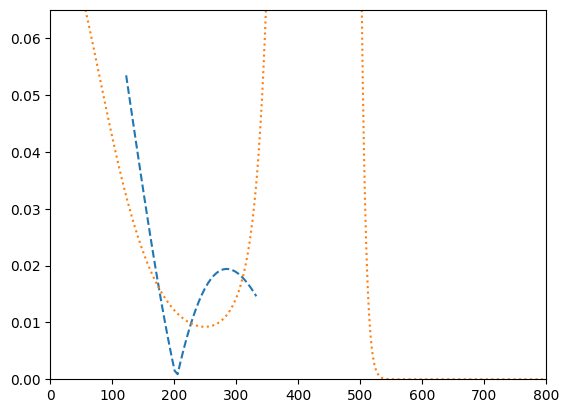

In [54]:
plt.plot(fc, mag_c, label="Reconstructed Magnitude (Bandlimited)", linestyle="dashed")
plt.plot(fl, np.exp(c0 + c2 * fl**2 + c4 * fl**4 * t), label="Polynomial Fit", linestyle="dotted")
plt.xlim(0, 800)
plt.ylim(0, 0.065)

In [46]:
A, B = -c2, c4
R = 6 * B / A**2

In [47]:
from scipy.special import gammaln, gamma
from scipy.optimize import brentq

def g(beta):
    return gammaln(1 / beta) + gammaln(5/beta) - 2 * gammaln(3 / beta) - np.log(R + 3)

beta = brentq(g, 0.1, 10)

alpha = np.sqrt((2 * A * gamma(1/beta)) / gamma(3/beta))

beta, alpha

(6.311917727234699, np.float64(0.0046604402219774365))

1.3375868462613387

In [ ]:
import numpy as np
from scipy.special import gammaln
from scipy.optimize import brentq

def beta_from_R(R):
    if not (-3 < R < -22/9):
        raise ValueError("For beta > 0, R must satisfy -3 < R < -22/9.")

    def g(beta):
        return (
            2*gammaln(3/beta)
            - gammaln(1/beta)
            - gammaln(5/beta)
            - np.log(R + 3)
        )

    # bracket on beta > 0
    return brentq(g, 1e-6, 1e6)

# example
R = -2.7
beta = beta_from_R(R)
print(beta)